## Spectral Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from data.dataset import SpectralDataset, Device
from data.data_loader import SpectralDataLoader
from preprocess.transform import Range_Clip

data_path = "./spectral_data"

## Testing the loading functions

In [2]:
devices= Device.get_devices()
device_names = Device.get_device_names()

for _device, _device_name in zip(devices, device_names):
    dataset = SpectralDataset(data_path, device=_device)
    print(_device_name, len(dataset), sep='\t|\t')

BIO_SCIENCE	|	1591
SCAN_CODER	|	1684
LOW_COST	|	807


## Testing dataloading for scan coder

In [3]:
dataset= SpectralDataset(data_path, Device.SCAN_CODER)
dataloader = SpectralDataLoader(dataset, batch_size=80, random=False)

data_iter = iter(dataloader)
x = next(data_iter)

# print(x[0])
cols = dataset.scan_corder_data.columns[3:]
df = dataset.scan_corder_data

## Testing dataloading for low cost spectrometer

In [4]:
dataset = SpectralDataset(data_path, Device.LOW_COST)
dataloader = SpectralDataLoader(dataset, batch_size=2, random=True)
data_iter = iter(dataloader)
x = next(data_iter)


## Testing dataloading for high end spectrometer

In [5]:
dataset = SpectralDataset(data_path, Device.BIO_SCIENCE)
dataloader = SpectralDataLoader(dataset, batch_size=80, random= True)

data_iter = iter(dataloader)
x = next(data_iter)
x.shape, dataset[0].shape

((80, 3648), (3648,))

## Testing High End Range Transform

In [11]:
range_transform = Range_Clip(lower_bound=450, upper_bound=900)
x_clipped, wavelength_clipped = range_transform.fit_transform(x, dataset.wavelength)

x_clipped.shape, x.shape, data.wavelength.shape, wavelength_clipped.shape

NameError: name 'data' is not defined

## Data Visualization for Scan Coder

In [6]:
def run_test():
    devices = Device.get_devices()
    device_names = Device.get_device_names()
    state_dict = dict()
    for device, device_name in zip(devices, device_names):
        dataset = SpectralDataset(data_path, device)
        dataloader = SpectralDataLoader(dataset, len(dataset), random= True)
        x_data = next(iter(dataloader))
        kmeans = KMeans(n_clusters=3, random_state=42)
        kmeans.fit(x_data)
        labels = kmeans.labels_
        centers = kmeans.cluster_centers_
        pca = PCA(n_components=2)
        x_pca = pca.fit_transform(x_data)
        state_dict[device_name] = {'labels': None, 'pca_components': None}
        state_dict[device_name]['labels'] = labels
        state_dict[device_name]['pca_components'] = x_pca
    return state_dict
state_dict = run_test()

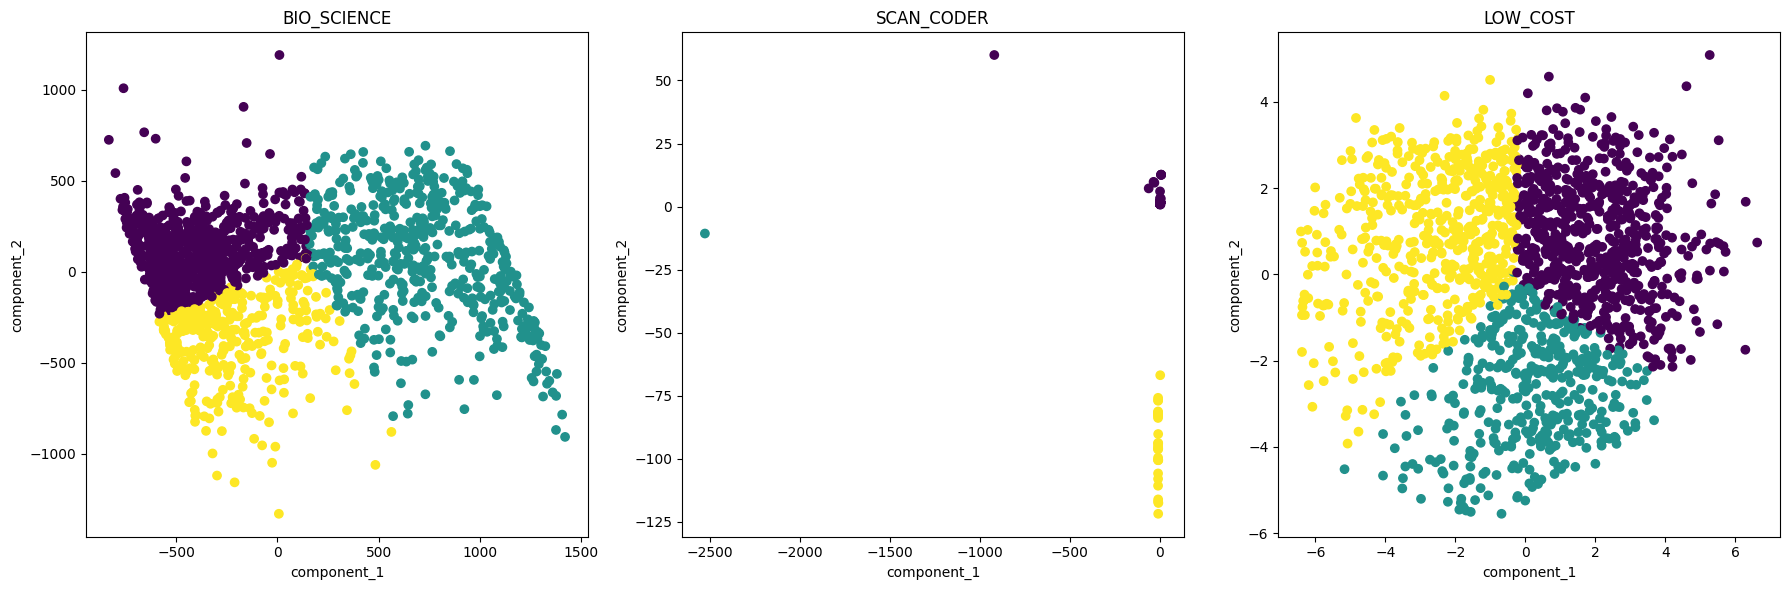

In [7]:
_keys = list(state_dict.keys())
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, _key in enumerate(state_dict.keys()):
    res_dict = state_dict[_key]
    labels, x_pca = res_dict['labels'], res_dict['pca_components']
    axes[i].scatter(x_pca[:, 0], x_pca[:, 1], c=labels)
    axes[i].set_xlabel('component_1')
    axes[i].set_ylabel('component_2')
    axes[i].set_title(_key)
plt.tight_layout()
fig.savefig('device_visualization.png')
plt.show()

In [94]:
x_pca = state_dict['SCAN_CODER']['pca_components']
x_pca[:, 0].shape, x_pca[:, 1].shape

((1684,), (1684,))